In [1]:
# Imports

import matplotlib.pyplot as plt
import numpy as np

# Import GraphUniverse components
from graph_universe import (
    GraphFamilyGenerator,
    GraphUniverse,
    GraphUniverseDataset,
    plot_graph_communities,
)

Converting graphs to PyG graphs: 100%|██████████| 10/10 [00:00<00:00, 1422.23it/s]


Sample graph properties:
- Nodes: 38
- Edges: 328
- Features shape: torch.Size([38, 10])
- Labels shape: torch.Size([38])


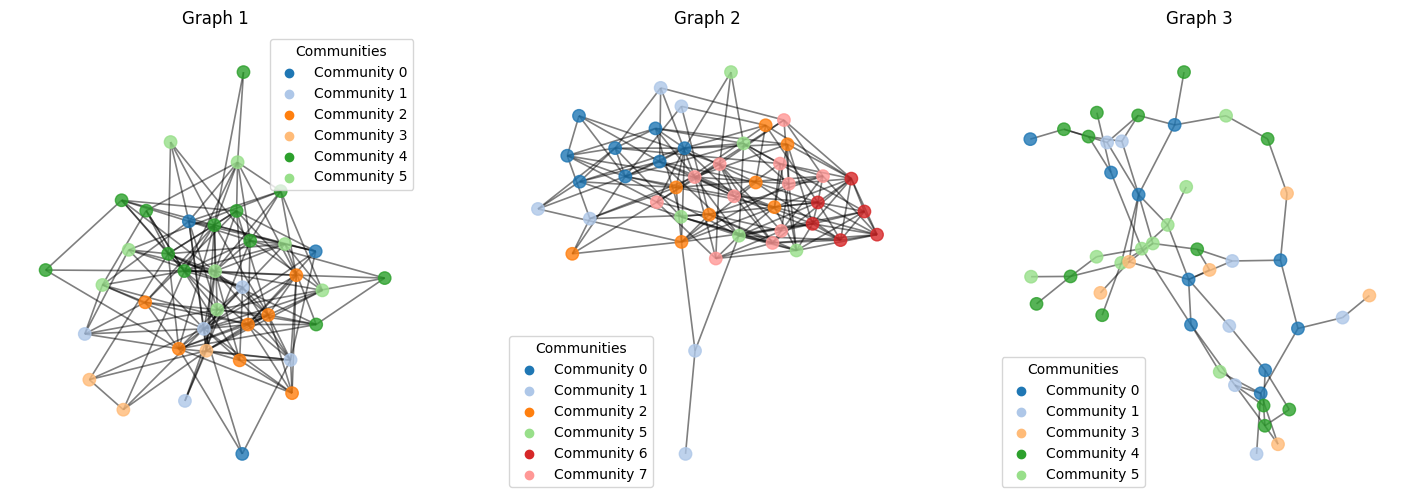

In [ ]:
# =============================================================================
# OPTION 1: GENERATE GRAPHS VIA INDIVIDUAL CLASSES
# =============================================================================

# Create universe
universe = GraphUniverse(K=8, edge_propensity_variance=0.3, feature_dim=10, cluster_variance=0.5, center_variance=0.2)

# Create Family Generator
family = GraphFamilyGenerator(
    universe=universe,
    n_nodes_range=(35, 50),
    n_communities_range=(2, 6),
    homophily_range=(0.2, 0.8),
    avg_degree_range=(2.0, 10.0),
    power_law_exponent_range=(2.0, 5.0),
    degree_separation_range=(0.1, 0.7),
    seed=42,
)

# Actually generate 10 graphs
family.generate_family(
    n_graphs=10,
    show_progress=True
)

# Convert to PyG graphs, ready for training on community detection task
pyg_graphs = family.to_pyg_graphs(task="community_detection")

# Select the first graph of the family
sample_graph = pyg_graphs[0]
print("Sample graph properties:")
print(f"- Nodes: {sample_graph.num_nodes}")
print(f"- Edges: {sample_graph.num_edges}")
print(f"- Features shape: {sample_graph.x.shape}")
print(f"- Labels shape: {sample_graph.y.shape}")

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Sample 3 random graph indices from the family with NO replacement if n_graphs > 3
if len(family.graphs) > 3:
    random_graph_indices = np.random.choice(len(family.graphs), size=3, replace=False)
else:
    random_graph_indices = np.random.choice(len(family.graphs), size=3, replace=True)

for idx, i in enumerate(random_graph_indices):
    graph = family.graphs[i]

    # Use GraphUniverse's plot_graph_communities function
    plot_graph_communities(
        graph=graph,
        layout="spring",
        node_size=80,
        edge_width=1.2,
        edge_alpha=0.5,
        with_labels=False,
        ax=axes[idx],
        title=f"Graph {idx+1}",
    )

# Show plot
plt.show()

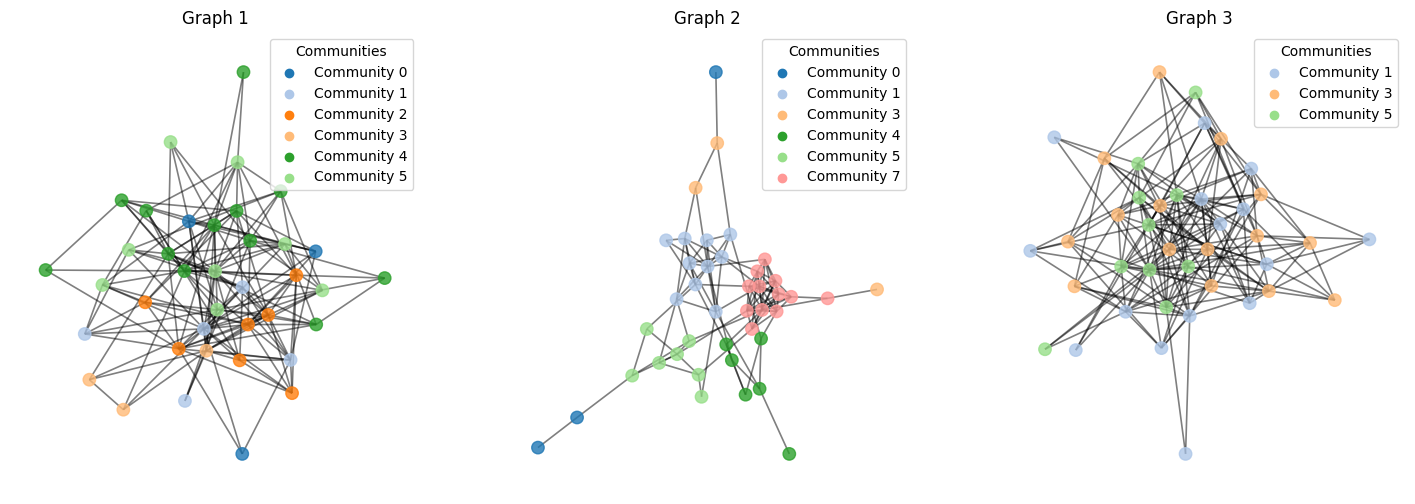

In [3]:
# =============================================================================
# OPTION 2: VIA YAML CONFIG FILE
# =============================================================================

experiment_config = {
    "universe_parameters": {
        "K": 10,
        "edge_propensity_variance": 0.5,
        "feature_dim": 16,
        "center_variance": 1.0,
        "cluster_variance": 0.3,
        "seed": 42
    },
    "family_parameters": {
        "n_graphs": 100,
        "n_nodes_range": [25, 200],
        "n_communities_range": [3, 7],
        "homophily_range": [0.1, 0.9],
        "avg_degree_range": [2.0, 8.0],
        "power_law_exponent_range": [2.0, 3.0],
        "degree_separation_range": [0.4, 0.8],
        "seed": 42,
    },
    "task": "community_detection"
}

dataset = GraphUniverseDataset(root="./data", parameters=experiment_config)

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Sample 3 random graph indices from the family with NO replacement if n_graphs > 3
if len(family.graphs) > 3:
    random_graph_indices = np.random.choice(len(family.graphs), size=3, replace=False)
else:
    random_graph_indices = np.random.choice(len(family.graphs), size=3, replace=True)

for idx, i in enumerate(random_graph_indices):
    graph = family.graphs[i]

    # Use GraphUniverse's plot_graph_communities function
    plot_graph_communities(
        graph=graph,
        layout="spring",
        node_size=80,
        edge_width=1.2,
        edge_alpha=0.5,
        with_labels=False,
        ax=axes[idx],
        title=f"Graph {idx+1}",
    )

# Show plot
plt.show()

In [2]:
# =============================================================================
# OPTION 3: INTERACTIVE UI VIA STREAMLIT
# =============================================================================

# To use the UI, you have two options:
# 1. Command line (recommended):
# $ graph-universe-ui
# 2. From Python (convenience wrapper):
# from graph_universe import launch_ui
# launch_ui()

# Here we show the UI in a notebook cell via the convenience wrapper

from graph_universe import launch_ui

launch_ui()  # Opens browser, press Ctrl+C to stop

2026-02-18 12:27:47.544 Credentials already loaded. Not rereading file.


Launching GraphUniverse Dashboard...
The dashboard will open in your browser.
Press Ctrl+C in this terminal to stop the server.


RuntimeError: Runtime instance already exists!